In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [75]:
sales_df = pd.read_csv('wroretail_sales.csv')
retail_df = pd.read_csv('wroclaw_retail.csv')
products_df = pd.read_csv('wroretail_products.csv')
simple_df = pd.read_csv('wroretail_simple.csv')
stores_df = pd.read_csv('wroretail_stores.csv')
holidays_df = pd.read_csv('polish_holidays_2021_2024.csv')

In [76]:
dfs = {
    "Sales": sales_df,
    "Retail": retail_df,
    "Simple": simple_df,
    "Products": products_df,
    "Stores": stores_df,
    "Holidays": holidays_df
}
print("--- SZYBKI PRZEGLĄD STRUKTURY DANYCH ---")

for name, df in dfs.items():
    print(f"\nTABELA: {name}")
    print(f"   Rozmiar: {df.shape}")
    display(df.head(1))
    print("-" * 50)

--- SZYBKI PRZEGLĄD STRUKTURY DANYCH ---

TABELA: Sales
   Rozmiar: (292200, 17)


,date,store_id,store_name,city,store_type,category,sales,n_transactions,is_holiday,holiday_name,days_to_holiday,days_from_holiday,is_weekend,day_of_week,month,year,season
0,2021-01-01,1,WroRetail Wroclaw Centrum,Wroclaw,hipermarket,Elektronika,1050.91,12,1,Nowy Rok,5,0,0,4,1,2021,zima


--------------------------------------------------

TABELA: Retail
   Rozmiar: (36500, 4)


,date,store_id,product_id,sales
0,2022-01-01,1,1,712.05


--------------------------------------------------

TABELA: Simple
   Rozmiar: (292200, 8)


...

--------------------------------------------------

TABELA: Stores
   Rozmiar: (10, 6)


,store_id,store_name,city,store_type,opening_year,sales_multiplier
0,1,WroRetail Wroclaw Centrum,Wroclaw,hipermarket,2015,1.5


--------------------------------------------------

TABELA: Holidays
   Rozmiar: (80, 5)


,date,holiday_name,is_public_holiday,is_shopping_boost,category_boost
0,2021-01-01,Nowy Rok,1,0,NaN


--------------------------------------------------


# A

In [77]:
df = dfs['Retail'].copy()
df['date'] = pd.to_datetime(df['date'])

df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['quarter'] = df['date'].dt.quarter
df['year'] = df['date'].dt.year
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

def get_season(month):
    if month in [3, 4, 5]: return 'spring'
    elif month in [6, 7, 8]: return 'summer'
    elif month in [9, 10, 11]: return 'autumn'
    return 'winter'
df['season'] = df['month'].apply(get_season)

holiday_series = pd.to_datetime(dfs['Holidays']['date'])
holiday_dates = np.sort(holiday_series.values.astype('datetime64[D]'))

def get_holiday_distances(row_date_ts):
    current_date = row_date_ts.to_datetime64().astype('datetime64[D]')
    
    diffs = (holiday_dates - current_date).astype(float)
    
    future_holidays = diffs[diffs >= 0]
    if len(future_holidays) > 0:
        days_until = np.min(future_holidays)
    else:
        days_until = 999 
        
    past_holidays = diffs[diffs <= 0]
    if len(past_holidays) > 0:
        days_since = np.min(np.abs(past_holidays))
    else:
        days_since = 999 
        
    return int(days_since), int(days_until)

unique_dates = df['date'].unique()
dist_map = {d: get_holiday_distances(pd.Timestamp(d)) for d in unique_dates}

df['days_since_holiday'], df['days_until_holiday'] = zip(*df['date'].map(dist_map))

display(df.head(3))

,date,store_id,product_id,sales,day_of_week,month,quarter,year,is_weekend,season,days_since_holiday,days_until_holiday
0,2022-01-01,1,1,712.05,5,1,1,2022,1,winter,0,0
1,2022-01-02,1,1,798.06,6,1,1,2022,1,winter,1,4
2,2022-01-03,1,1,482.66,0,1,1,2022,0,winter,2,3


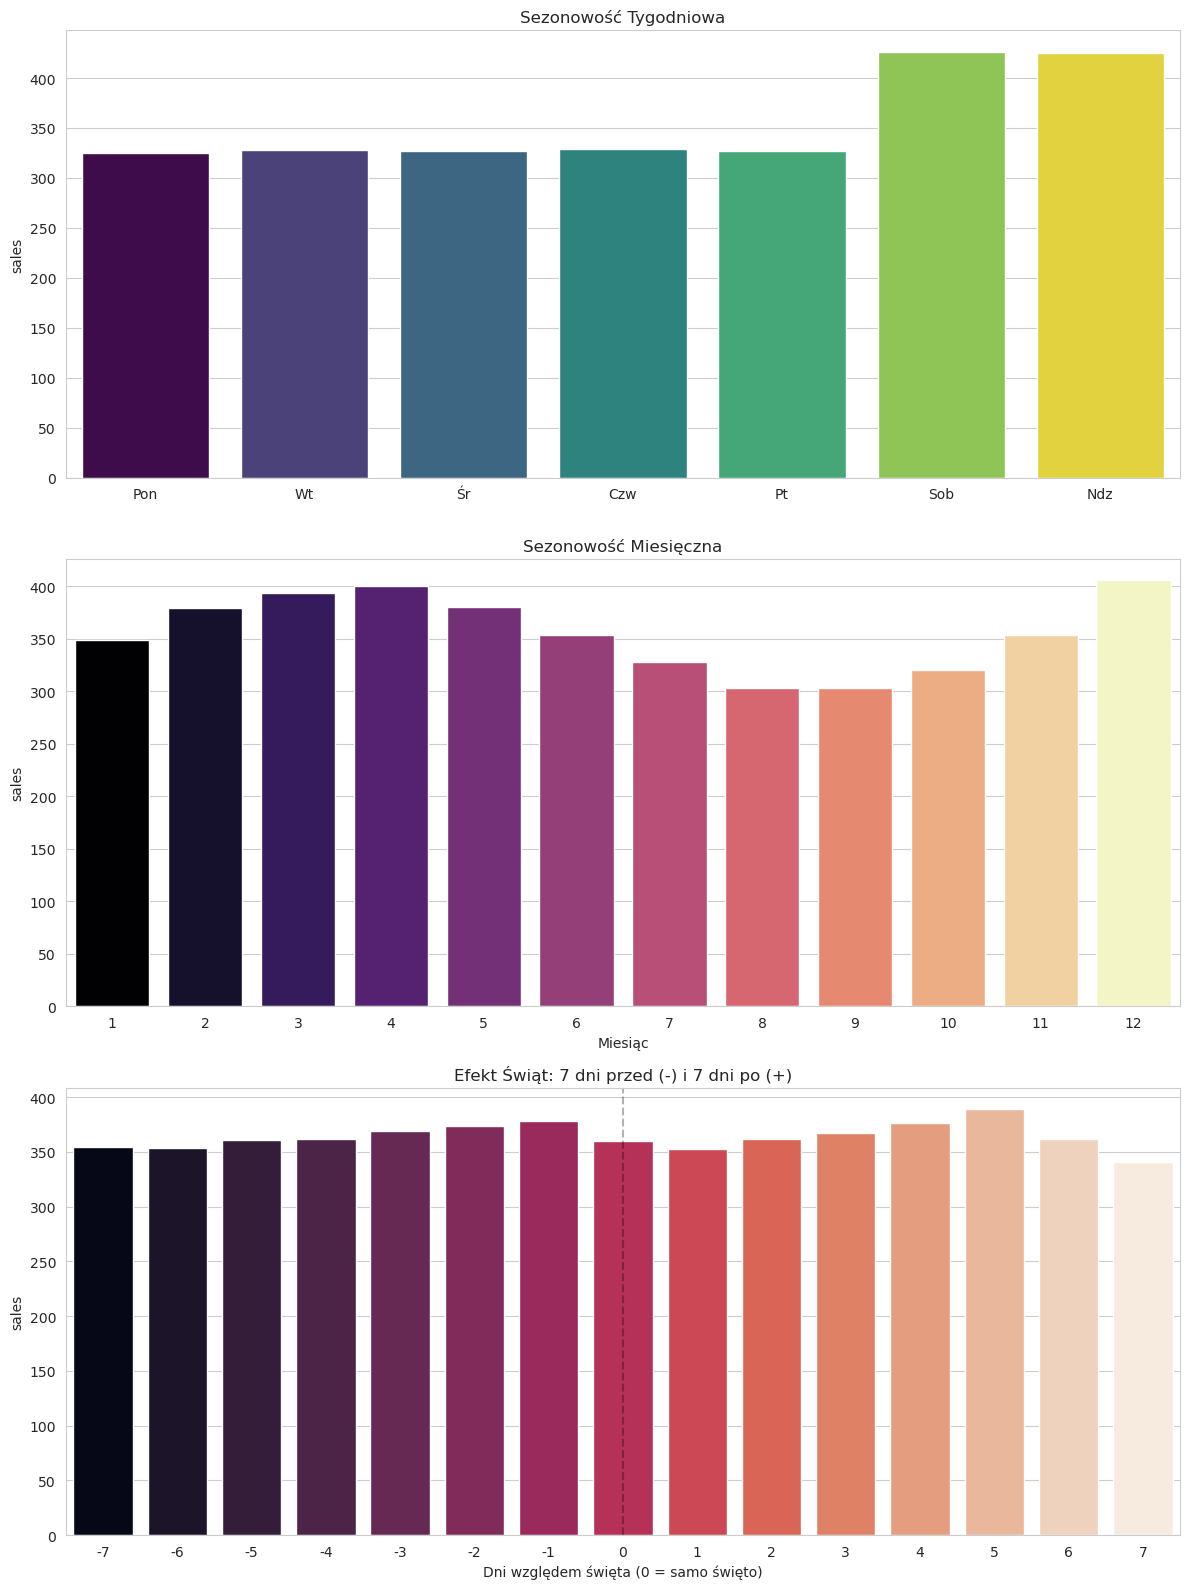

In [78]:
sns.set_style("whitegrid")

# Przygotowanie danych do wykresu świątecznego (+/- 7 dni)
mask_before = df['days_until_holiday'] <= 7
mask_after = df['days_since_holiday'] <= 7

df_before = df[mask_before].copy()
df_before['rel_day'] = -df_before['days_until_holiday']

df_after = df[mask_after].copy()
df_after['rel_day'] = df_after['days_since_holiday']

df_holiday = pd.concat([df_before, df_after])
df_holiday = df_holiday.sort_values('rel_day')

# Rysowanie
fig, axes = plt.subplots(3, 1, figsize=(12, 16))

# 1. Tygodniowa
sns.barplot(data=df, x='day_of_week', y='sales', hue='day_of_week', ax=axes[0], palette='viridis', errorbar=None, legend=False)
axes[0].set_title('Sezonowość Tygodniowa')
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(['Pon', 'Wt', 'Śr', 'Czw', 'Pt', 'Sob', 'Ndz'])
axes[0].set_xlabel('')

# 2. Miesięczna
sns.barplot(data=df, x='month', y='sales', hue='month', ax=axes[1], palette='magma', errorbar=None, legend=False)
axes[1].set_title('Sezonowość Miesięczna')
axes[1].set_xlabel('Miesiąc')

# 3. Efekt Świąt (+/- 7 dni)
sns.barplot(data=df_holiday, x='rel_day', y='sales', hue='rel_day', ax=axes[2], palette='rocket', errorbar=None, legend=False)
axes[2].set_title('Efekt Świąt: 7 dni przed (-) i 7 dni po (+)')
axes[2].set_xlabel('Dni względem święta (0 = samo święto)')
axes[2].axvline(x=7, color='black', linestyle='--', alpha=0.3) 

plt.tight_layout()
plt.show()

# B

In [79]:
df = df.sort_values(['store_id', 'product_id', 'date'])

grp = df.groupby(['store_id', 'product_id'])['sales']

df['sales_lag_1'] = grp.shift(1).fillna(0)
df['sales_lag_7'] = grp.shift(7).fillna(0)
df['sales_lag_28'] = grp.shift(28).fillna(0)

df['rolling_mean_7'] = grp.transform(
    lambda x: x.shift(1).rolling(window=7, min_periods=1).mean()
)

df['rolling_mean_28'] = grp.transform(
    lambda x: x.shift(1).rolling(window=28, min_periods=1).mean()
)

df['rolling_std_7'] = grp.transform(
    lambda x: x.shift(1).rolling(window=7, min_periods=1).std()
).fillna(0) 

cols = ['date', 'sales', 'sales_lag_1', 'rolling_mean_7']

display(df[df['store_id']==1].head(10)[cols])

,date,sales,sales_lag_1,rolling_mean_7
0,2022-01-01,712.05,0.00,NaN
1,2022-01-02,798.06,712.05,712.050000
2,2022-01-03,482.66,798.06,755.055000
3,2022-01-04,483.14,482.66,664.256667
4,2022-01-05,619.95,483.14,618.977500
5,2022-01-06,559.48,619.95,619.172000
6,2022-01-07,466.86,559.48,609.223333
7,2022-01-08,706.73,466.86,588.885714
8,2022-01-09,608.71,706.73,588.125714
9,2022-01-10,468.53,608.71,561.075714
